# ARCH (q)
Autoregressive conditional heteroskedascity

In econometrics, the autoregressive conditional heteroskedasticity (ARCH) model is a statistical model for time series data that describes the variance of the current error term or innovation as a function of the actual sizes of the previous time periods' error terms;often the variance is related to the squares of the previous innovations. The ARCH model is appropriate when the error variance in a time series follows an autoregressive (AR) model; if an autoregressive moving average (ARMA) model is assumed for the error variance, the model is a generalized autoregressive conditional heteroskedasticity (GARCH) model.

ARCH models are commonly employed in modeling financial time series that exhibit time-varying volatility and volatility clustering, i.e. periods of swings interspersed with periods of relative calm. ARCH-type models are sometimes considered to be in the family of stochastic volatility models, although this is strictly incorrect since at time t the volatility is completely pre-determined (deterministic) given previous values.



$$ 
\sigma_t^{2}=\omega+\sum_{i=1}^{p}\alpha_{i}\epsilon_{t-i}^{2} 
$$ 

# GARCH (p,q)
Generalized autoregressive conditional heteroskedasticity

In econometrics, the autoregressive conditional heteroskedasticity (ARCH) model is a statistical model for time series data that describes the variance of the current error term or innovation as a function of the actual sizes of the previous time periods' error terms; often the variance is related to the squares of the previous innovations. The ARCH model is appropriate when the error variance in a time series follows an autoregressive (AR) model; if an autoregressive moving average (ARMA) model is assumed for the error variance, the model is a generalized autoregressive conditional heteroskedasticity (GARCH) model.

ARCH models are commonly employed in modeling financial time series that exhibit time-varying volatility and volatility clustering, i.e. periods of swings interspersed with periods of relative calm. ARCH-type models are sometimes considered to be in the family of stochastic volatility models, although this is strictly incorrect since at time t the volatility is completely pre-determined (deterministic) given previous values.

In this class of processes, the variance dynamics are

$$
\sigma_{t}^{2}=\omega
+ \sum_{i=1}^{p}\alpha_{i}\epsilon_{t-i}^{2}
+\sum_{k=1}^{q}\beta_{k}\sigma_{t-k}^{2}
$$ 

In [35]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn

seaborn.set_style("darkgrid")
plt.rc("figure", figsize=(16, 6))
plt.rc("savefig", dpi=90)
plt.rc("font", family="sans-serif")
plt.rc("font", size=14)

# import pandas_datareader.data as web
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modeling
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",80)

In [36]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-04-17


In [37]:
%%time
start_date = "2018-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT",]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
all_data.info()

The number of stock to download are 10
[*********************100%***********************]  10 of 10 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1330 entries, 2018-01-02 00:00:00-05:00 to 2023-04-14 00:00:00-04:00
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1330 non-null   float64
 1   (Adj Close, DIS)    1330 non-null   float64
 2   (Adj Close, KO)     1330 non-null   float64
 3   (Adj Close, MAT)    1330 non-null   float64
 4   (Adj Close, META)   1330 non-null   float64
 5   (Adj Close, MSFT)   1330 non-null   float64
 6   (Adj Close, NVDA)   1330 non-null   float64
 7   (Adj Close, PFE)    1330 non-null   float64
 8   (Adj Close, TSLA)   1330 non-null   float64
 9   (Adj Close, ^GSPC)  1330 non-null   float64
 10  (Close, AAPL)       1330 non-null   float64
 11  (Close, DIS)        1330 non-null   float64
 12  (Close, KO)         1330 non-null   float64


In [38]:
adj_close_data_completed = all_data["Adj Close"].copy()
adj_close_data_completed.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.888073,108.726059,38.548203,16.020000,181.419998,80.738159,49.326290,28.559778,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.880943,109.192848,38.463558,16.139999,184.669998,81.113899,52.572651,28.771395,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.070835,109.144241,39.005302,15.910000,184.330002,81.827827,52.849777,28.834089,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.538441,108.551003,38.996834,16.260000,186.850006,82.842339,53.297626,28.888954,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.384159,106.994995,38.937584,15.810000,188.279999,82.926880,54.930698,28.567617,22.427334,2747.709961


In [39]:
yield_data = adj_close_data_completed.pct_change().dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004293,-0.002196,0.007491,0.017914,0.004654,0.065814,0.007410,-0.010233,0.006399
2018-01-04 00:00:00-05:00,0.004645,-0.000445,0.014085,-0.014250,-0.001841,0.008802,0.005271,0.002179,-0.008290,0.004029
2018-01-05 00:00:00-05:00,0.011385,-0.005435,-0.000217,0.021999,0.013671,0.012398,0.008474,0.001903,0.006230,0.007034
2018-01-08 00:00:00-05:00,-0.003714,-0.014334,-0.001519,-0.027675,0.007653,0.001021,0.030641,-0.011123,0.062638,0.001662
2018-01-09 00:00:00-05:00,-0.000115,-0.000727,0.005000,0.000632,-0.002178,-0.000680,-0.000270,-0.001097,-0.008085,0.001303


In [40]:
df_log = np.log(yield_data + 1)#.dropna()
df_log.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004284,-0.002198,0.007463,0.017756,0.004643,0.063739,0.007382,-0.010286,0.006378
2018-01-04 00:00:00-05:00,0.004634,-0.000445,0.013986,-0.014353,-0.001843,0.008763,0.005257,0.002177,-0.008325,0.004021
2018-01-05 00:00:00-05:00,0.011321,-0.005450,-0.000217,0.021760,0.013579,0.012322,0.008438,0.001901,0.006210,0.007009
2018-01-08 00:00:00-05:00,-0.003721,-0.014438,-0.001521,-0.028065,0.007624,0.001020,0.030181,-0.011185,0.060755,0.001661
2018-01-09 00:00:00-05:00,-0.000115,-0.000727,0.004988,0.000632,-0.002180,-0.000680,-0.000270,-0.001098,-0.008118,0.001302


In [41]:
from arch import arch_model


returns = yield_data["AAPL"]*100

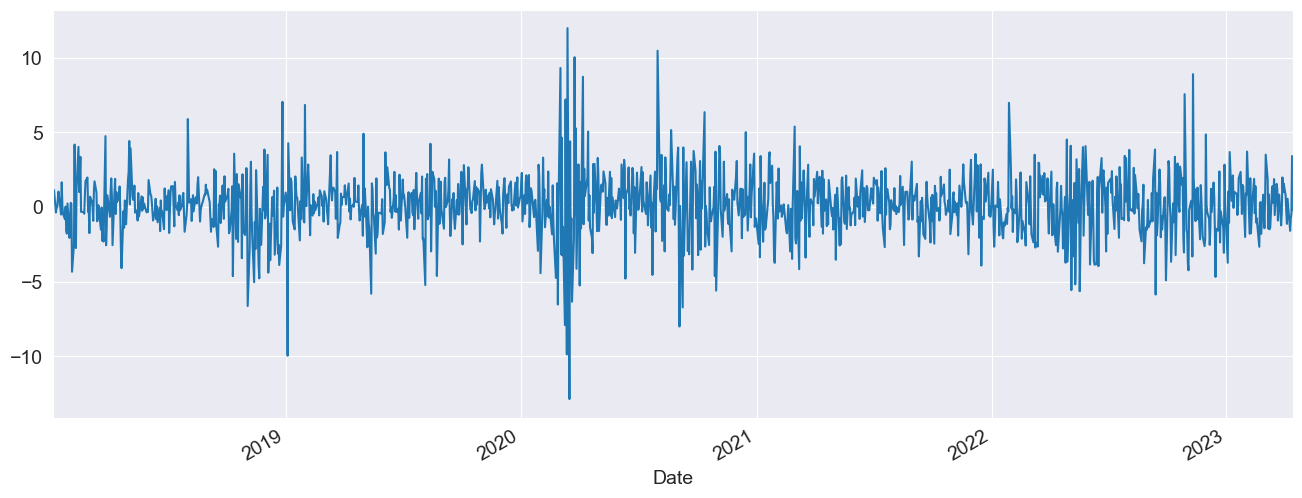

In [42]:
ax = returns.plot()
xlim = ax.set_xlim(returns.index.min(), returns.index.max())

In [43]:
am = arch_model(returns)

res = am.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 8063.761647093789
Iteration:      2,   Func. Count:     16,   Neg. LLF: 146061076232.2213
Iteration:      3,   Func. Count:     24,   Neg. LLF: 3297.503013750429
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3214.6378515192437
Iteration:      5,   Func. Count:     38,   Neg. LLF: 2722.057385524303
Iteration:      6,   Func. Count:     44,   Neg. LLF: 2721.71930188182
Iteration:      7,   Func. Count:     49,   Neg. LLF: 2721.7182702271116
Iteration:      8,   Func. Count:     54,   Neg. LLF: 2721.718170511771
Iteration:      9,   Func. Count:     59,   Neg. LLF: 2721.7181611671294
Iteration:     10,   Func. Count:     64,   Neg. LLF: 2721.7181602750593
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2721.7181602750593
            Iterations: 10
            Function evaluations: 64
            Gradient evaluations: 10


In [44]:
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2721.72
Distribution:                  Normal   AIC:                           5451.44
Method:            Maximum Likelihood   BIC:                           5472.21
                                        No. Observations:                 1329
Date:                Tue, Apr 18 2023   Df Residuals:                     1328
Time:                        19:11:11   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2346  5.036e-02      4.658  3.188e-06 [  0.136,  0.33

In [47]:
from arch import arch_model

am = arch_model(returns)
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     38,   Neg. LLF: 2722.057385524303
Iteration:     10,   Func. Count:     64,   Neg. LLF: 2721.7181602750593
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2721.7181602750593
            Iterations: 10
            Function evaluations: 64
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2721.72
Distribution:                  Normal   AIC:                           5451.44
Method:            Maximum Likelihood   BIC:                           5472.21
                                        No. Observations:                 1329
Date:                Tue, Apr 18 2023   Df Residuals:                     1328
Time:        

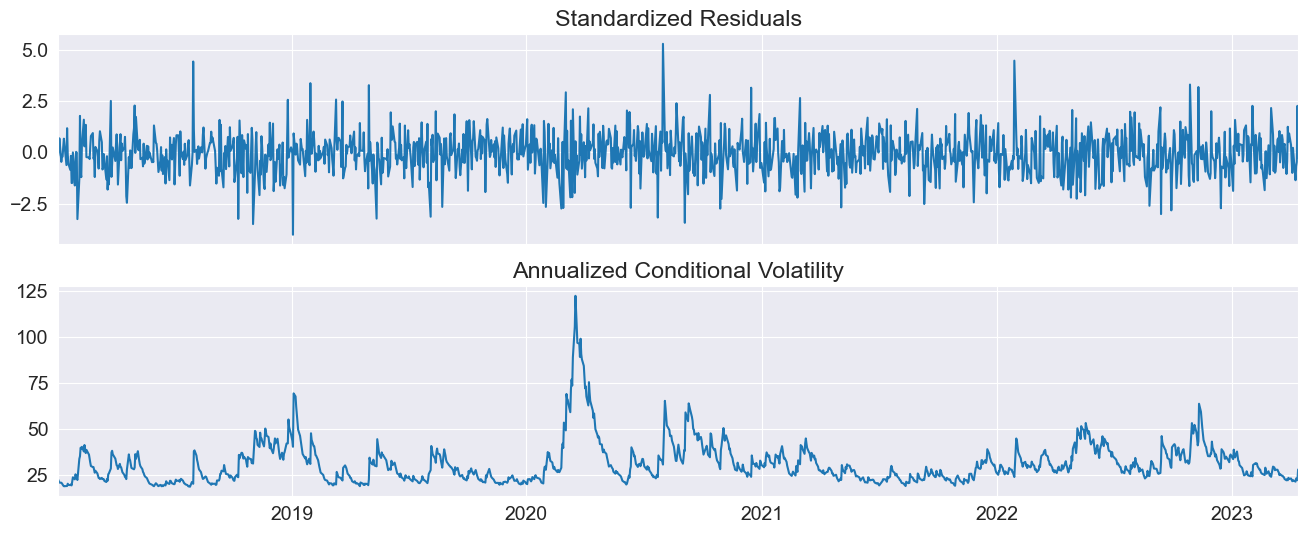

In [48]:
fig = res.plot(annualize="D")

## ARCH Model

In [58]:
am = arch_model(
    returns, 
    vol="ARCH",
    p = 3,
    q=0,
    o=0,
    dist = 'normal'
)

am.fit()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 6127.090466769818
Iteration:      2,   Func. Count:     16,   Neg. LLF: 284561.4136060961
Iteration:      3,   Func. Count:     24,   Neg. LLF: 5329.571553450566
Iteration:      4,   Func. Count:     32,   Neg. LLF: 6448.376693366761
Iteration:      5,   Func. Count:     40,   Neg. LLF: 2808.1750367387585
Iteration:      6,   Func. Count:     48,   Neg. LLF: 2768.875480521916
Iteration:      7,   Func. Count:     54,   Neg. LLF: 2768.8752171599454
Iteration:      8,   Func. Count:     59,   Neg. LLF: 2768.875217159938
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2768.8752171599454
            Iterations: 8
            Function evaluations: 59
            Gradient evaluations: 8


                      Constant Mean - ARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -2768.88
Distribution:                  Normal   AIC:                           5547.75
Method:            Maximum Likelihood   BIC:                           5573.71
                                        No. Observations:                 1329
Date:                Tue, Apr 18 2023   Df Residuals:                     1328
Time:                        19:25:13   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1758  5.253e-02      3.346  8.207e-04 [7.280e-0

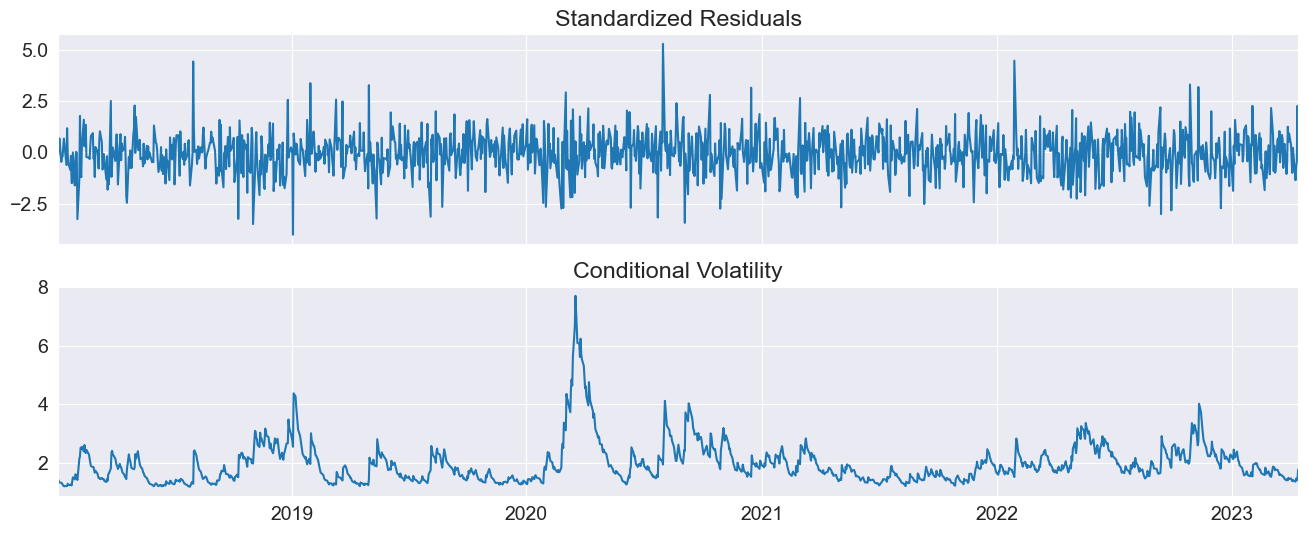

In [59]:
fig = res.plot()